<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/read_wav_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Created by EDES**


mainly helped by claude-ai

Downloaded to local_wav_0.wav
Downloaded to local_wav_1.wav
Downloaded to local_wav_2.wav
Downloaded to local_wav_3.wav
Downloaded to local_wav_4.wav
Downloaded to local_wav_5.wav
Downloaded to local_wav_6.wav
data-0 length:165375 - rate:44100Hz - max_val:0.20678962767124176 @ 77143
data-1 length:165375 - rate:44100Hz - max_val:0.22090013325214386 @ 77140
data-2 length:165375 - rate:44100Hz - max_val:0.18920716643333435 @ 77175
data-3 length:165375 - rate:44100Hz - max_val:0.18075722455978394 @ 77141
data-4 length:165375 - rate:44100Hz - max_val:0.17937374114990234 @ 77138
data-5 length:165375 - rate:44100Hz - max_val:0.1833767294883728 @ 77175
data-6 length:165375 - rate:44100Hz - max_val:0.12392235547304153 @ 77141


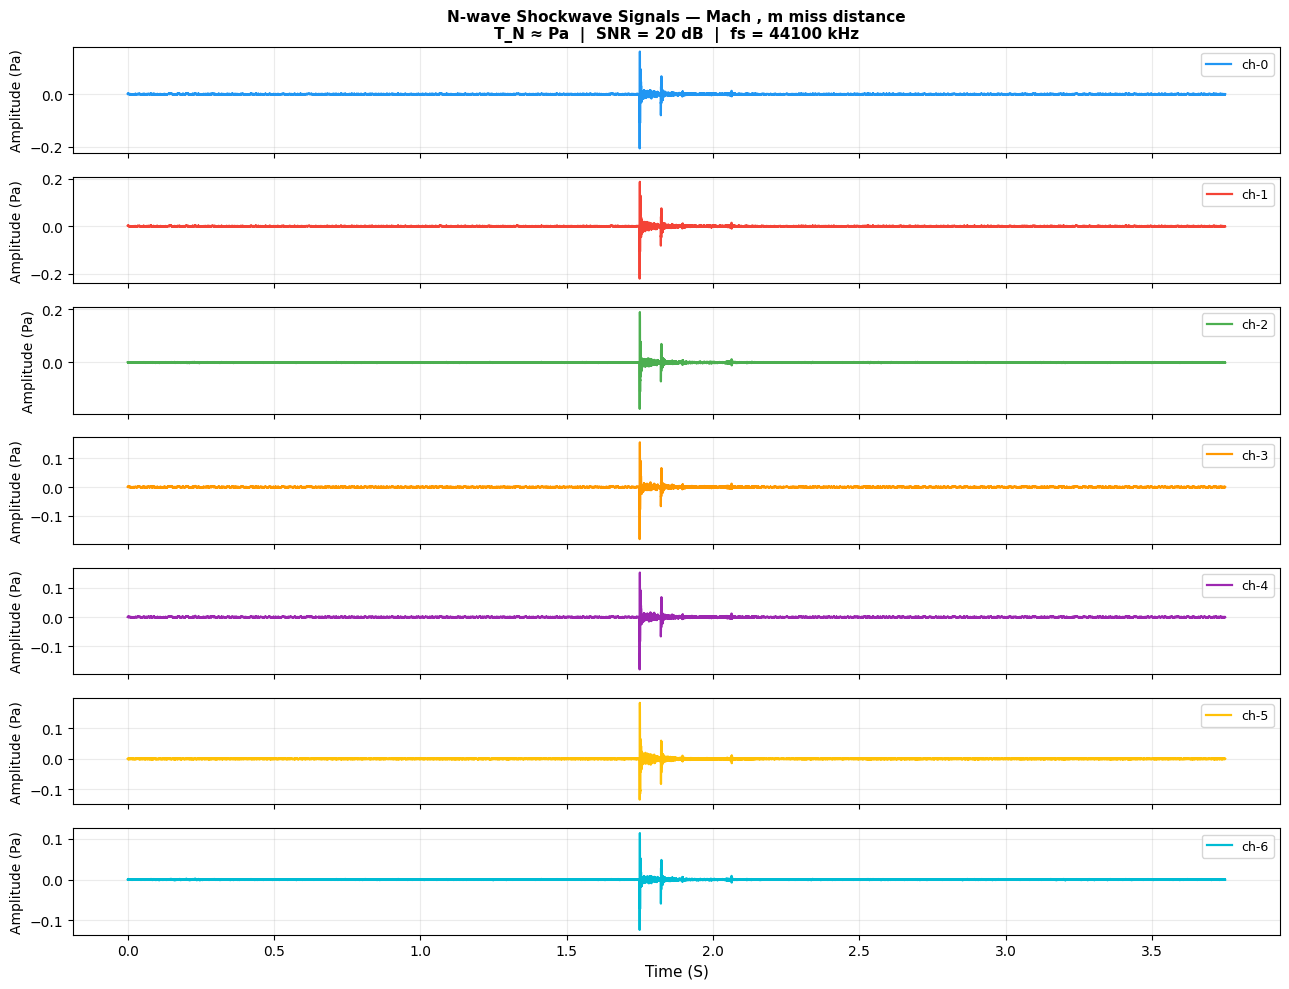

In [20]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

wav_file_url=[]
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch0.wav')
#wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch1.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch2.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch3.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch4.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch5.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch6.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_mean.wav')

num_files = len(wav_file_url)

local_file = []
for i in range(num_files):
  local_file.append(f'local_wav_{i}.wav')

# Check if the URL is provided
for i in range(num_files):
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url[i]}...")
        response = requests.get(wav_file_url[i])
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_file[i], 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_file[i]}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_file[i]}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

dataset_signal=[]; max_amplitude_val=[]; max_amplitude_idx=[]
for i in range(num_files):
  dataset_samplerate, dataset = wavfile.read(local_file[i])
  if dataset.ndim > 1:
    dataset = dataset[:, 0] # Take the first channel
  dataset_signal.append(dataset)
  max_amp_idx = np.argmax(np.abs(dataset))
  max_amp_val = np.max(np.abs(dataset))
  max_amplitude_idx.append(max_amp_idx)
  max_amplitude_val.append(max_amp_val)
  print(f"data-{i} length:{len(dataset)} - rate:{dataset_samplerate}Hz - max_val:{max_amp_val} @ {max_amp_idx}")

# Create a time array for the x-axis for the (possibly cropped) data
dataset_time = np.linspace(0., len(dataset) / dataset_samplerate, len(dataset))

COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#FFC107', '#00BCD4', '#8BC34A']

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — Mach , '
    f'm miss distance\n'
    f'T_N ≈ Pa  |  '
    f'SNR = 20 dB  |  fs = {dataset_samplerate} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

starting index for cropping:77015


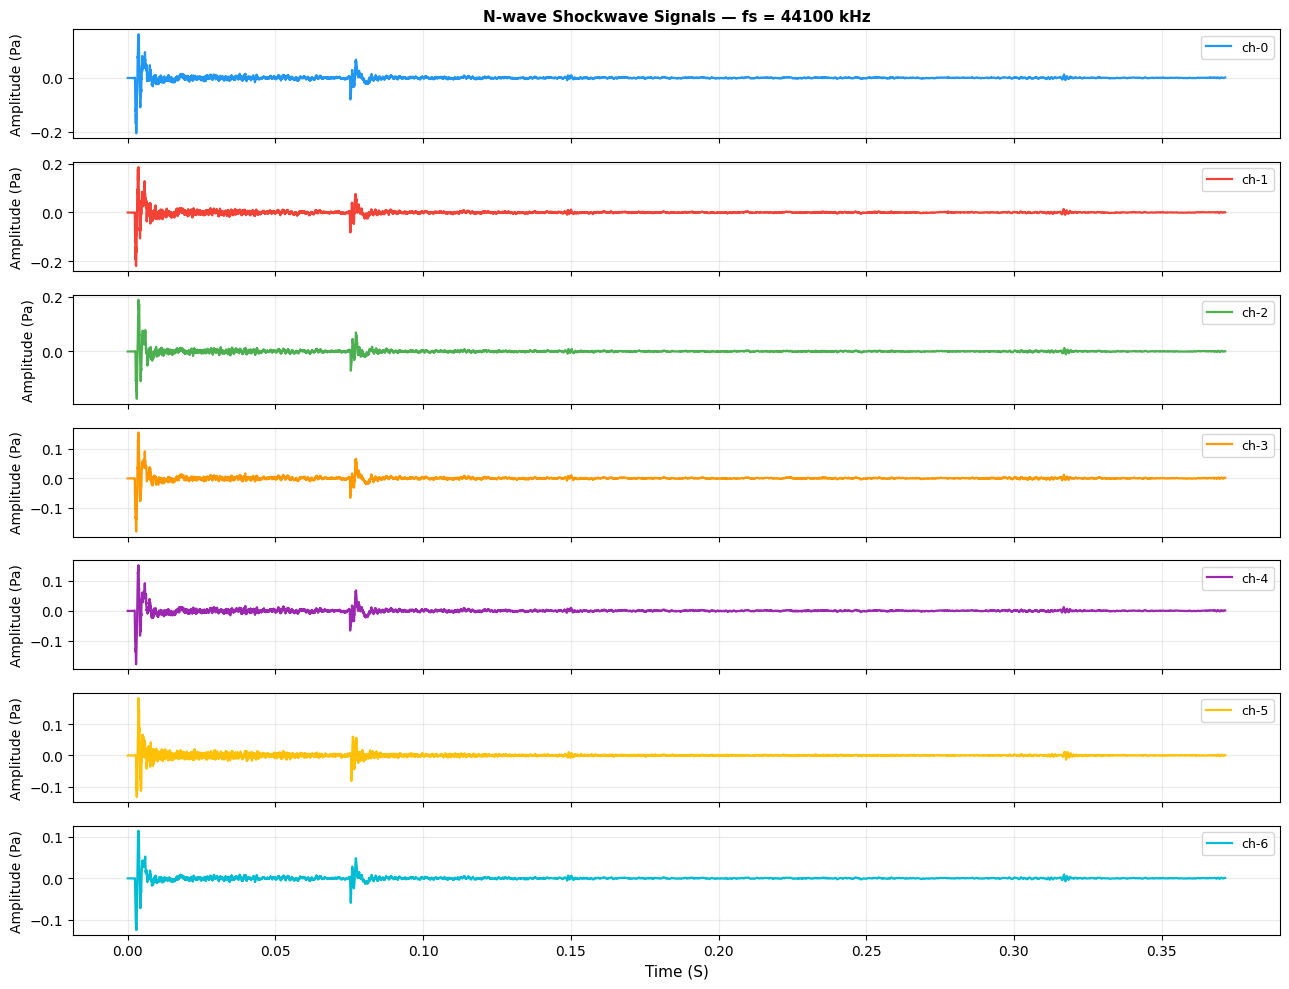

In [21]:
target_length = 2**13 # 16384 samples
smallest_offset = max(0, int(max_amplitude_idx[0] - 128))
print(f"starting index for cropping:{smallest_offset}")

for i in range(num_files):
  end_idx = smallest_offset + target_length
  dataset_signal[i] = dataset_signal[i][smallest_offset:end_idx]

dataset_time = np.linspace(0., target_length / dataset_samplerate, target_length)

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — fs = {dataset_samplerate} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

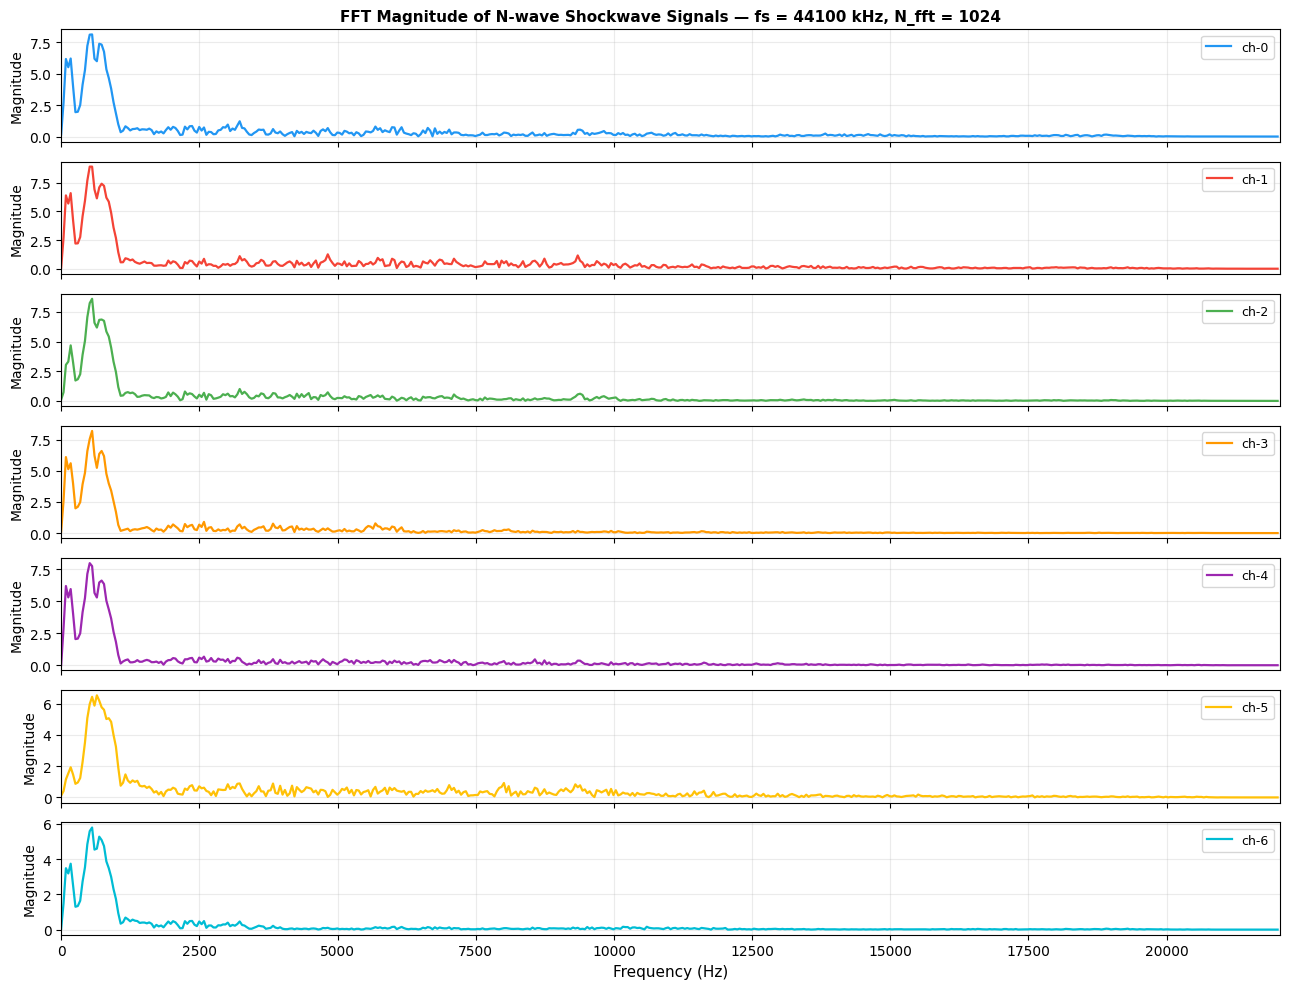

In [22]:
from scipy.fft import fft, fftfreq

# N_fft is already defined as 1024. For this FFT calculation, we will use N_fft.
# This means the FFT will be computed over 1024 samples. If the signal is longer
# than N_fft, it will effectively truncate or consider the first N_fft samples
# of the provided signal for the FFT, or it implies zero-padding if the signal is shorter.

N_fft = 1024 # Use the N_fft variable as the FFT length

# Calculate FFT and frequencies for each signal
freqs = fftfreq(N_fft, 1 / dataset_samplerate)

fig, axes_fft = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    # Compute FFT for the current signal using N_fft_actual points
    # If the signal length is greater than N_fft_actual, it will be truncated.
    yf = fft(dataset_signal[i], n=N_fft)
    # Take the magnitude and normalize, and consider only the positive frequencies
    magnitude = np.abs(yf[:N_fft // 2])

    ax = axes_fft[i]
    ax.plot(freqs[:N_fft // 2], magnitude, color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Magnitude', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim([0, dataset_samplerate / 2]) # Limit x-axis to Nyquist frequency

axes_fft[-1].set_xlabel('Frequency (Hz)', fontsize=11)
axes_fft[0].set_title(
    f'FFT Magnitude of N-wave Shockwave Signals — fs = {dataset_samplerate} kHz, N_fft = {N_fft}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

GCC-PHAT  (x16 zero-padding -> 1.417 us resolution)
----------------------------------------------------------------
Pair      True tau (us)   Est tau (us)    Error (us)
  (0,1)           -93.537   
  (0,2)          +137.472   
  (0,3)           -59.524   
  (0,4)           -90.703   
  (0,5)          +330.215   
  (0,6)          +147.392   


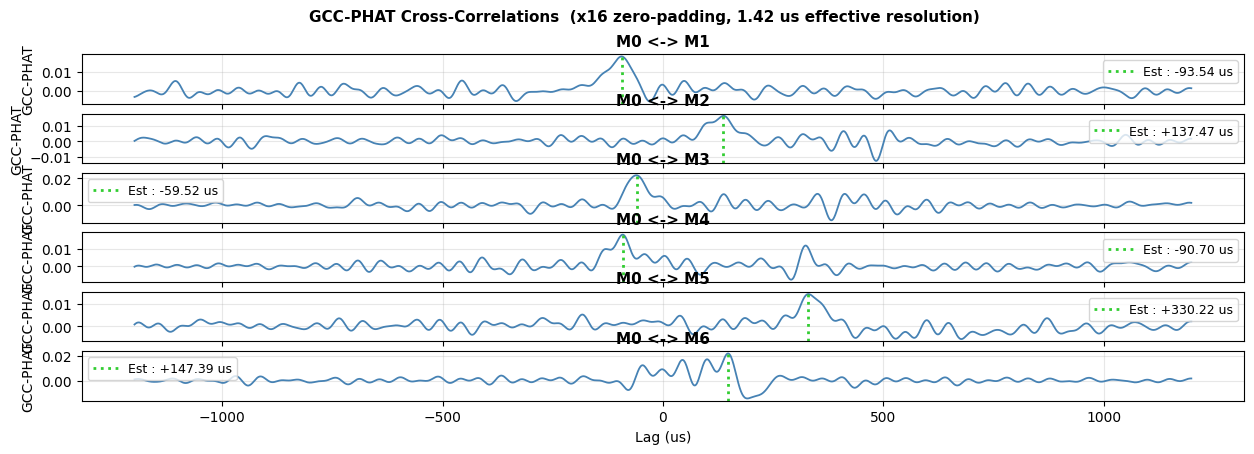

In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 8.1 — GCC-PHAT Algorithm & Shockwave TDOA                              ║
# ╚══════════════════════════════════════════════════════════════════════════════════╝
#  Algorithm
#  ---------
#  1. FFT both signals with n = N (native resolution, no time-domain zero-pad).
#  2. PHAT-weighted cross-spectrum:  G(f) = X1(f).X2*(f) / |X1(f).X2*(f)|
#  3. TDOA = argmax_tau { IFFT(G, zero-padded to n*interp_factor)[tau] }
#     (zero-padding in the FREQUENCY domain before the inverse FFT is what
#     gives sub-sample TDOA resolution -- doing it in the time domain before
#     the forward FFT instead causes a lag-scaling bug.)
#
#  At fs = 100 kHz, x16 zero-padding -> effective resolution = 0.625 us.
#
#  Reference: Knapp & Carter (1976), "The generalised cross-correlation
#             method for estimation of time delay", IEEE Trans. ASSP.
C     = 343.0      # Speed of sound (m/s) -- ISA sea level
L_ARRAY = 0.30

def gcc_phat(x1, x2, fs, interp_factor=16, max_lag_s=None):
    n = len(x1)
    X1 = np.fft.rfft(x1, n=n)
    X2 = np.fft.rfft(x2, n=n)
    G  = X2 * np.conj(X1)              # x2 relative to x1 (positive tau = x2 arrives later)
    G /= (np.abs(G) + 1e-12)
    nf = n * interp_factor
    cc = np.fft.fftshift(np.fft.irfft(G, n=nf))   # interpolation happens HERE
    lags = np.arange(-nf//2, nf//2) / (fs * interp_factor)
    if max_lag_s is None:
        max_lag_s = 1.5 * L_ARRAY / C
    mask = np.abs(lags) <= max_lag_s
    idx  = np.argmax(cc[mask])
    return lags[mask][idx], cc, lags

FS = dataset_samplerate
INTERP = 16
dt_eff = 1e6 / (FS * INTERP)

print(f"GCC-PHAT  (x{INTERP} zero-padding -> {dt_eff:.3f} us resolution)")
print("-" * 64)
print(f"{'Pair':<8} {'True tau (us)':>14} {'Est tau (us)':>14} {'Error (us)':>13}")

tdoa_results = {}
for i in range(1, num_files):
    tau_est, cc, lags = gcc_phat(dataset_signal[0], dataset_signal[i], FS, interp_factor=INTERP)
    tdoa_results[i]   = (tau_est, cc, lags)
    print(f"  (0,{i})    {tau_est*1e6:>+14.3f}   ")

fig, axes_g = plt.subplots(num_files-1, 1, figsize=(15, 4.5))
WIN_GCC = 1.2e-3

for idx, i in enumerate(range(1, num_files)):
    tau_est, cc, lags = tdoa_results[i]
    ax = axes_g[idx]
    view = np.abs(lags) <= WIN_GCC
    ax.plot(lags[view]*1e6, cc[view], color='steelblue', lw=1.3)
    ax.axvline(tau_est*1e6,  color='limegreen', ls=':',  lw=2.0,
               label=f'Est : {tau_est*1e6:+.2f} us')
    ax.set_xlabel('Lag (us)', fontsize=10)
    ax.set_ylabel('GCC-PHAT', fontsize=10)
    ax.set_title(f'M0 <-> M{i}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

fig.suptitle(
    f'GCC-PHAT Cross-Correlations  '
    f'(x{INTERP} zero-padding, {dt_eff:.2f} us effective resolution)',
    fontsize=11, fontweight='bold')
#plt.tight_layout()
plt.savefig('gcc_phat.png', dpi=150, bbox_inches='tight')
plt.show()